<a href="https://colab.research.google.com/github/LightSoyMilk/Learning-ML/blob/main/learn_california_housing_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Step 0. Getting the dataset from Kaggle, and importing libraries
- This is to get the dataset from Kaggle and linking it to Google Colab.
- The code cell underneath is to import the necessary libraries and functions for our project.
- The link to the dataset online is listed here in the URL: https://www.kaggle.com/datasets/camnugent/california-housing-prices

In [1]:
# Getting the dataset from Kaggle

from google.colab import files
#import opendatasets as od

upload = files.upload()

#od.download('https://www.kaggle.com/datasets/camnugent/california-housing-prices') # if asked, insert personal kaggle api key (from json file)

Saving housing.csv to housing.csv


In [2]:
# importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn import datasets
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

# Step 1. Exploratory Data Analysis
- The rudimentary when it comes to all ML project, here we will load the dataset, see if there are any null values in columns, and visually see the data as to how they are distributed to prepare for preprocessing.
- First we will just have the dataset on display and look at general statistics regarding them, and the number of null values.
- Then we will move onto visualizing the data to have a better grasp of the relationships between features, and how the data is distributed.

In [3]:
"""
These next code cells will involve us just looking at the csv file, gaining general
statistics about it, and checking for null values
"""

# Loading the data from the csv file
housing_df = pd.read_csv('/content/housing.csv')

# Printing the housing dataframe to see the general content of the csv file
housing_df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [4]:
# Getting the general statistics regarding the dataset, does not include non-numerical attributes
housing_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
# Checking for null columns and where they are exactly
housing_df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [6]:
"""
Dropping the ocean_proximity column and feature engineering two new features
"""
housing_df["bedroom_ratio"] = housing_df["total_bedrooms"] / housing_df["total_rooms"] # Average bedroom ratio per total room
housing_df["room_ratio"] = housing_df["total_rooms"] / housing_df["households"] # Average rooms in a house per household

housing_numeric_attr = housing_df.drop("ocean_proximity", axis = 1) # the axis=1 tells pandas to drop a column rather than a row (which would be axis=0)

# Making the matrix (without ocean proximity)
correlation_matrix = housing_numeric_attr.corr()

# Getting the correlation coefficients
cor_coef_numericft = correlation_matrix["median_house_value"].sort_values(ascending = False)
print("Correlation Coefficients:", cor_coef_numericft)
# At the end, we can see that the median_income of an area has a significant sway in determining the house prices of a district

Correlation Coefficients: median_house_value    1.000000
median_income         0.688075
room_ratio            0.151948
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
bedroom_ratio        -0.255880
Name: median_house_value, dtype: float64


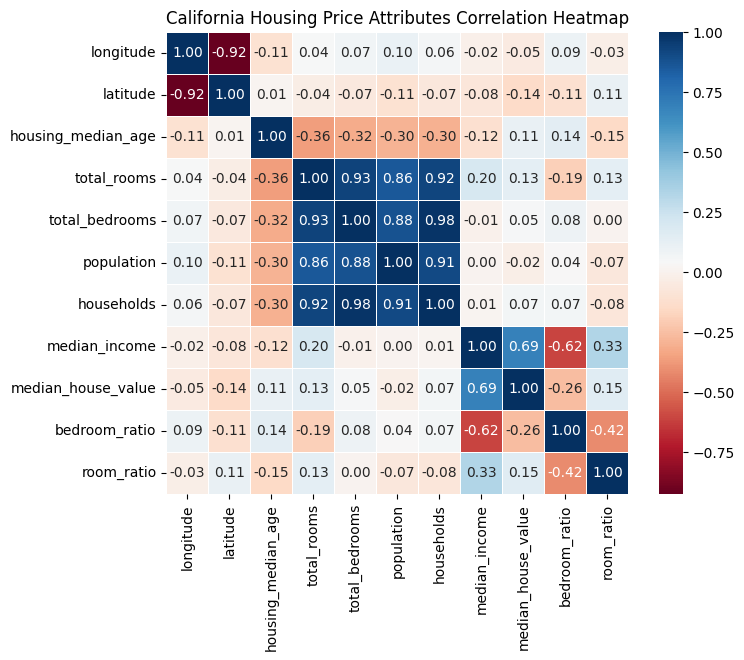

In [7]:
"""
These next code cells will involve us visualizing the relationship between
attributes/features in determining the median price of houses in a district,
how these attributes are distributed in regards to the Bell Curve shape and
and whether or not there is a huge difference in data range - since machine
learning model does best with normally distributed data (bell curve shaped) and
we do not want a huge difference in between range of features since the feature
with higher range would dominate the model because their numbers are bigger
"""

# Making the heatmap for the numeric features correlation matrix
plt.figure(figsize = (8, 6))
sns.heatmap(correlation_matrix, annot = True, cmap = 'RdBu', fmt = '.2f', linewidths = 0.5, square = True)
plt.title("California Housing Price Attributes Correlation Heatmap")
plt.show()

<Axes: xlabel='median_income', ylabel='median_house_value'>

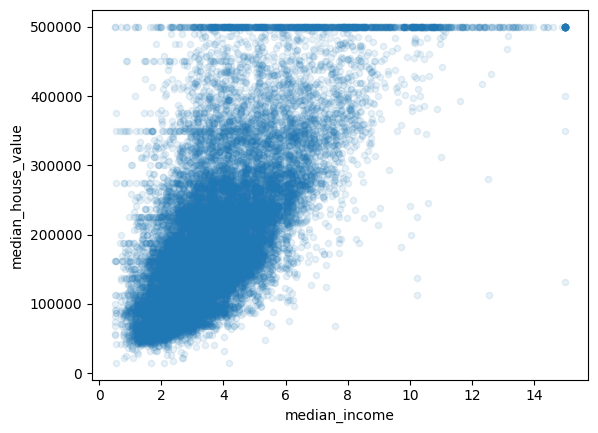

In [8]:
# Here, we will make a scatterplot to see the correlation between median income
# and median house prices, and see if there is really a strong relationship
housing_df.plot(kind = "scatter",
                x = "median_income", y = "median_house_value",
                alpha = 0.1)
# It seems like there is a strong correlation between the 2, with both having an
# upward trend and are not too dispersed

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>],
       [<Axes: title={'center': 'bedroom_ratio'}>,
        <Axes: title={'center': 'room_ratio'}>, <Axes: >]], dtype=object)

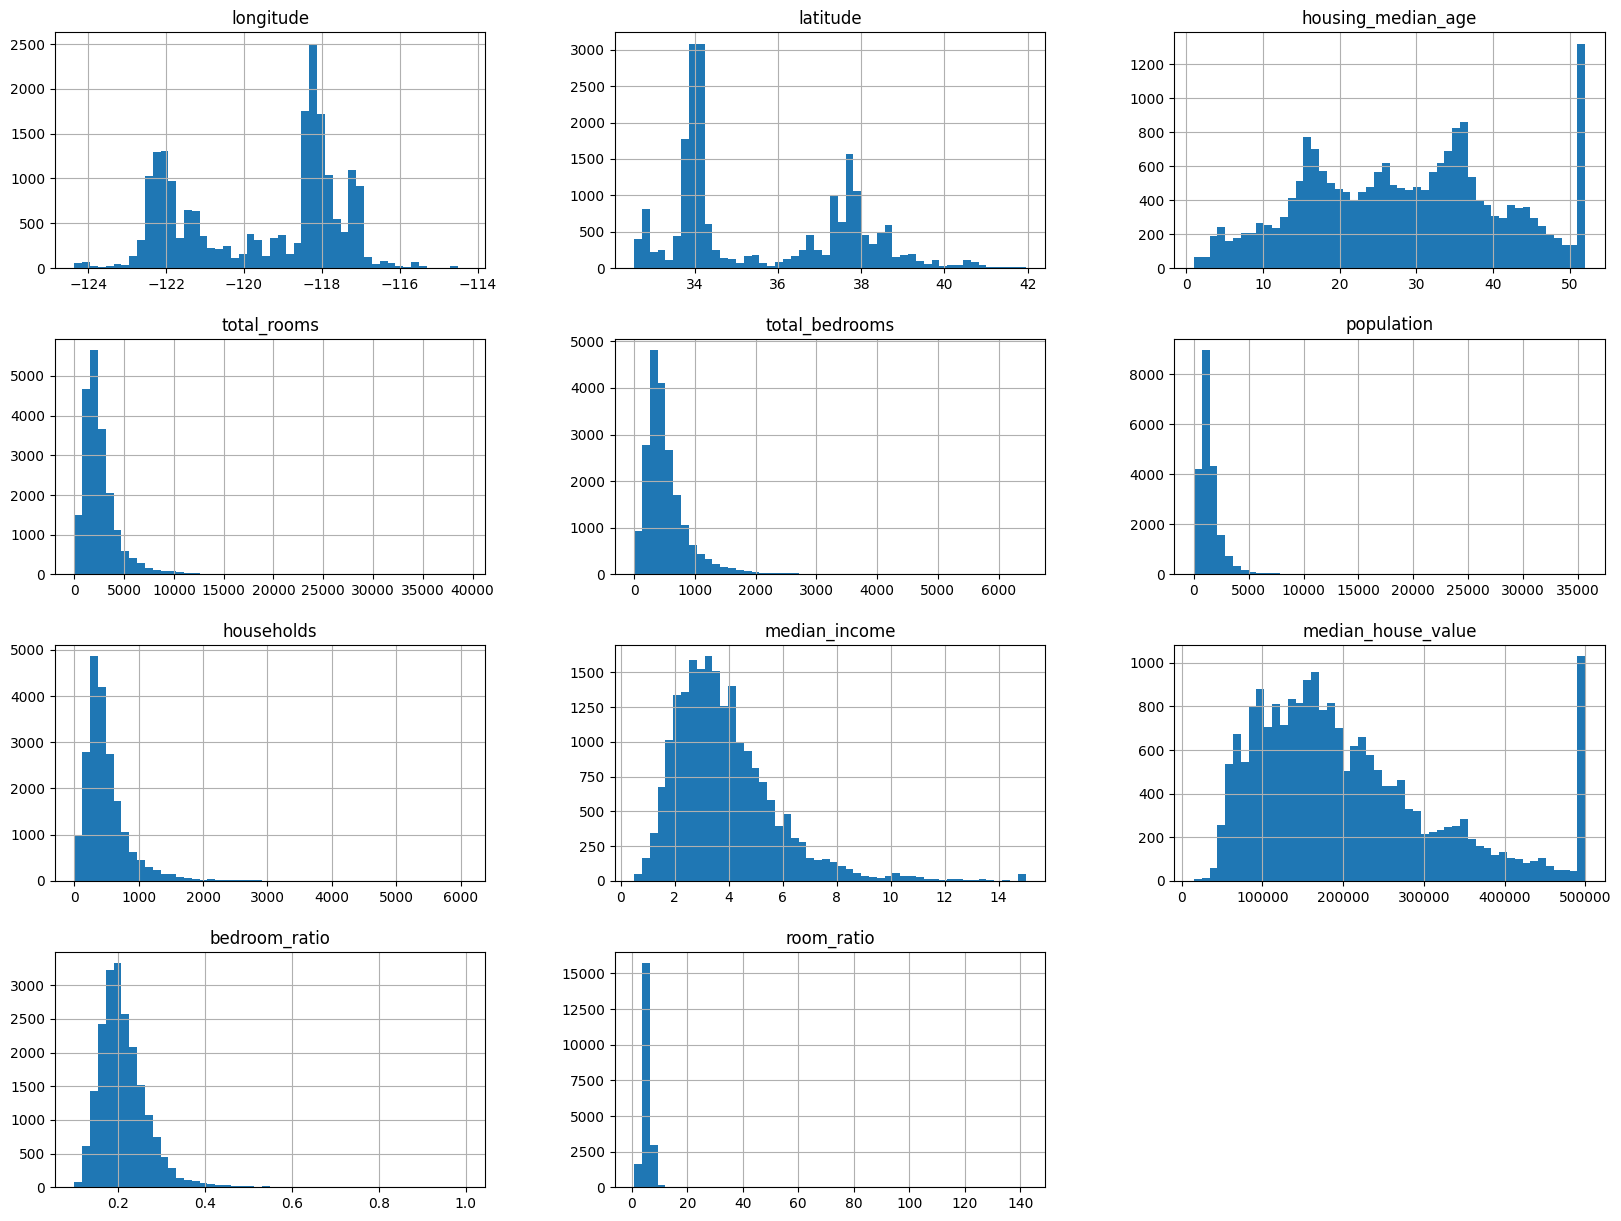

In [9]:
# Here, we will make a histogram for all the numeric features of our dataset, to see their distribution
housing_numeric_attr.hist(bins = 50, figsize = (20, 15))

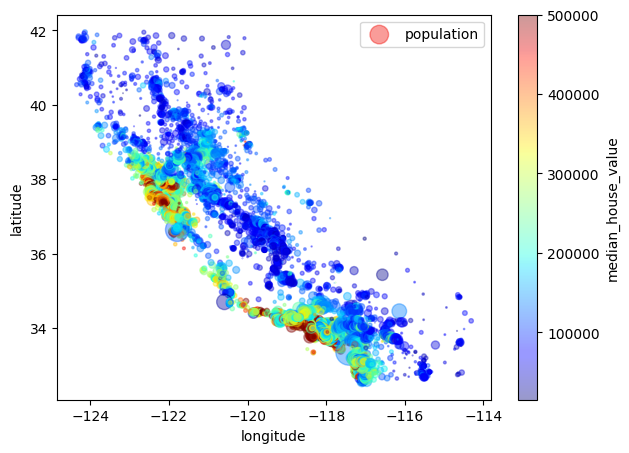

In [10]:
"""
Here, we will make a scatter diagram based on longitude, and latitude to see
the distribution of house prices across California, with a redder colour indicating
higher prices and circle's size indicating the population density
# Glossary:
- alpha: indicates the transparency of the plotted elements between 0-1, with 0
being invisible and 1 being fully solid. Any values in-between shows a semi-transparent effect
allowing us to see overlapping elements better.
- s: it controls the size of each element - in this case the districts' population.
It changes the area of the circle for the element.
- c: it is used for the colours of the scatter plot - in this case the colours of
an element is based on its median house price.
"""

housing_df.plot(kind = "scatter", x = "longitude", y = "latitude", alpha = 0.4,
                s = housing_df["population"]/100, label = "population", figsize = (7, 5),
                c = "median_house_value", cmap = plt.get_cmap("jet"), colorbar = True)
plt.legend()

**Observed features:**
- Through observations we see in numeric features, and visualization of those feature in this dataset, we can see the following things
---
- median_income seems to be the strongest indicator for a district's housing price.
- There are 207 rows with missing values for the number of total bedrooms in a district.
- From visualizing the data and getting the shape of the state of California, it seems that the houses on the left side of the state - being closer to the ocean have a deeper colour for the house prices. This warrants a deeper analysis into the ocean_proximity column that we dropped.
- From the histogram for the features, we can see that 6 features: total_rooms, total_bedrooms, population, households, bedroom_ratio, and room_ratio; have a right skewed distribution - meaning the tail is on the right side of the graph, or that most of the values are on the left side of the mean. This can be fixed in the processing step for better model performance.
- Also from the histogram, we can observe that the range between features differ quite a bit, with population having its' range between 0-8000, while housing_median_age only going from 0-1200. We can fix this by scaling the features in the processing step.

# Step 2. Data Preprocessing
- **This is where we will manipulate and correct unwanted data, and the distribution of our dataset.**
- It seems that while going over the number of rows in the dataset, we have counted a total of 20640 rows with data for every single features besides total bedroom, which shows that there are 207 rows with missing values for the total bedrooms for houses in a Californian district.
- Here, we will process the housing's total_bedrooms dataframe in 2 ways:
---
- The first way is to drop all the rows with null values for total bedrooms - meaning districts with missing data for their houses' total bedrooms are disregarded for the model.
- The second approach is to impute/fill in the null rows of missing bedrooms with the median number of bedrooms in the dataset and also include the ocean proximity feature.
---
- For the skewed features, we will apply techniques to standardize them (get them into a bell curve shape).
- Another thing that we would have to do is to Scale the features using a StandardScaler so the dataset the model works on, would not be dominated by features with a higher range.
- And finally, we will OneHotEncode the ocean proximity column to use that as a feature for our model as well - based on the observation from the scatter plot.

**Rows with Nulls: Drop or Impute**

In [11]:
# This code cell will address the missing total_bedrooms rows, either by dropping them or imputing them

# This is the dataframe that drops the rows with null values, and creates a new df
housing_df_dropnull = housing_df.dropna(subset = ["total_bedrooms"])
housing_df_dropnull = housing_df_dropnull.drop(columns = ["ocean_proximity"])
housing_df_dropnull_copy = housing_df_dropnull.copy()

"""
Underneath here, we will create a simple imputer to fill in the rows with missing
total_bedrooms with the median number of total_bedrooms in the dataset
"""

# The steps to impute the numeric only df, since we can't impute categories

imputer = SimpleImputer(strategy = "median")
imputer.fit(housing_numeric_attr) # we are only imputing the numeric attributes
housing_numeric_imputed = imputer.transform(housing_numeric_attr)
print("Imputer return data type: ", type(housing_numeric_imputed))
print()
# the variable above is in a ndarray datatype so we would have to convert it back into a pandas dataframe

# Converting the ndarray back to pandas dataframe
housing_num_df = pd.DataFrame(
    housing_numeric_imputed, columns = housing_numeric_attr.columns, index = housing_numeric_attr.index
)

# Printing the info of the numeric_attribute to see if there are any null values left
print(housing_num_df.info())

Imputer return data type:  <class 'numpy.ndarray'>

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20640 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   bedroom_ratio       20640 non-null  float64
 10  room_ratio          20640 non-null  float64
dtypes: float64(11)
memory usage: 1.7 MB
None


**Log Transform**

In [12]:
"""
# Here we would log transform the 6 skewed features to achieve a Bell curve, meaning we do not want our features to
be skewed. That would be bad since the model would learn on the majority and ignore the minority cases on the end that is not skewed.
# We would have to add 1 into the value before taking their log because log(1) = 0, and the log of negative values are undefined
so this is just a workaround to ensure that we don't run into log transforming negative values.
"""
# We will log transform both the df with dropped null values and the df with imputed values

# housing_df_dropnull transformation
housing_df_dropnull_copy.loc[:, 'population'] = np.log1p(housing_df_dropnull_copy['population'])
housing_df_dropnull_copy.loc[:, 'total_rooms'] = np.log1p(housing_df_dropnull_copy['total_rooms'])
housing_df_dropnull_copy.loc[:, 'total_bedrooms'] = np.log1p(housing_df_dropnull_copy['total_bedrooms'])
housing_df_dropnull_copy.loc[:, 'households'] = np.log1p(housing_df_dropnull_copy['households'])
housing_df_dropnull_copy.loc[:, 'bedroom_ratio'] = np.log1p(housing_df_dropnull_copy['bedroom_ratio'])
housing_df_dropnull_copy.loc[:, 'room_ratio'] = np.log1p(housing_df_dropnull_copy['room_ratio'])

# housing_num_imputedDf transformation
housing_num_df.loc[:, 'population'] = np.log1p(housing_num_df['population'])
housing_num_df.loc[:, 'total_rooms'] = np.log1p(housing_num_df['total_rooms'])
housing_num_df.loc[:, 'total_bedrooms'] = np.log1p(housing_num_df['total_bedrooms'])
housing_num_df.loc[:, 'households'] = np.log1p(housing_num_df['households'])
housing_num_df.loc[:, 'bedroom_ratio'] = np.log1p(housing_num_df['bedroom_ratio'])
housing_num_df.loc[:, 'room_ratio'] = np.log1p(housing_num_df['room_ratio'])

**Standard Scaler**

In [13]:
"""
Standard Scaling the features will be done later on the whole training set for features,
as we want the range of the features to be relatively close to each other. This is
to prevent features that have a higher range like Longitude, and Latitude, or Population
to dominate the model. Since they have on average a higher numerical value
"""

'\nStandard Scaling the features will be done later on the whole training set for features,\nas we want the range of the features to be relatively close to each other. This is\nto prevent features that have a higher range like Longitude, and Latitude, or Population\nto dominate the model. Since they have on average a higher numerical value\n'

**One Hot Encode**

In [14]:
'''
Here we will account for the Ocean Proximity feature by turning how close the houses
in a district are to the ocean is into a numerical feature the model could work on through
the use of OneHotEncoding
'''

# Extract the 'ocean_proximity' column from the original housing_df
housing_cat_feature = housing_df[['ocean_proximity']]

# Initialize OneHotEncoder
one_hot_encoder = OneHotEncoder(sparse_output=False) # sparse_output=False returns a dense numpy array

# Fit and transform the categorical feature
housing_cat_one_hot_encoded_array = one_hot_encoder.fit_transform(housing_cat_feature)

# Create a DataFrame from the one-hot encoded array
housing_cat_one_hot_encoded = pd.DataFrame(
    housing_cat_one_hot_encoded_array,
    columns=one_hot_encoder.get_feature_names_out(['ocean_proximity']),
    index=housing_df.index
)

# Concatenate the numerical DataFrame with the one-hot encoded categorical features
housing_transformed = pd.concat([housing_num_df, housing_cat_one_hot_encoded], axis=1)

print(housing_transformed.head())

# Store the names of the newly created one-hot encoded columns
categorical_columns = housing_cat_one_hot_encoded.columns.tolist()
# print("New categorical columns after OneHotEncoding:", categorical_columns)

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0     6.781058        4.867534   
1    -122.22     37.86                21.0     8.867850        7.009409   
2    -122.24     37.85                52.0     7.291656        5.252273   
3    -122.25     37.85                52.0     7.150701        5.463832   
4    -122.25     37.85                52.0     7.395108        5.638355   

   population  households  median_income  median_house_value  bedroom_ratio  \
0    5.777652    4.844187         8.3252            452600.0       0.136793   
1    7.784057    7.037906         8.3014            358500.0       0.144790   
2    6.208590    5.181784         7.2574            352100.0       0.121789   
3    6.326149    5.393628         5.6431            341300.0       0.169286   
4    6.338594    5.560682         3.8462            342200.0       0.158793   

   room_ratio  ocean_proximity_<1H OCEAN  ocean_proximity_INLAND  \
0    2

# Step 3. Creating the models with 2 different datasets
**Variation 1** - Simple: We would drop all the rows with missing values and not include the Ocean Proximity feature

**Variation 2** We would impute the rows with missing values and include the
Ocean Proximity feature


We will use pipelines here, instead of using our transformed datasets. The reason why is because I just wanted to learn how data can be preprocessed in the background. By employing pipelines, it is easier to ensure consistency and simplicity for our datasets






In [15]:
"""
Variation 1: Numerical only - Dropping all rows with missing values and the Ocean Proximity feature
"""

# Define numerical and categorical features
other_features = ["longitude", "latitude", "housing_median_age", "median_income"]
log_features = ["total_rooms", "total_bedrooms", "population",
                "households", "bedroom_ratio", "room_ratio"]
features_simple = other_features + log_features
cat_features = ["ocean_proximity"]

# Define transformers
scaler = StandardScaler() # Standardization for numerical features to ensure no huge gaps in range
log_transform = FunctionTransformer(np.log1p, validate = True)

# Numerical Pipeline that outlines the preprocessing steps to undertake in sequence
log_features_transform = Pipeline([
    ("log", log_transform),
    ("std_scaler", scaler)
])

# Column Transformer for all of the features
full_pipeline = ColumnTransformer([
    ("num_log", log_features_transform, log_features),
    ("scale", scaler, other_features)
])

# Define the target and features for the pipelined model and the manual processed model
X_simple = housing_df_dropnull[features_simple]
y_simple = housing_df_dropnull['median_house_value']

X_manual = housing_df_dropnull_copy[features_simple]
y_manual = housing_df_dropnull_copy['median_house_value']

# Split into training and testing sets and scaling the manual model
X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(X_simple, y_simple, test_size = 0.2, random_state = 42)
X_train_manual, X_test_manual, y_train_manual, y_test_manual = train_test_split(X_manual, y_manual, test_size = 0.2, random_state = 42)

X_manual = scaler.fit_transform(X_train_manual)
X_test = scaler.transform(X_test_manual)

# Display the shape of the data
print(f"Training test shape: {X_train_simple.shape}")
print(f"Testing test shape: {X_test_simple.shape}")

print(f"Training test shape: {X_train_manual.shape}")
print(f"Testing test shape: {X_test_manual.shape}")

Training test shape: (16346, 10)
Testing test shape: (4087, 10)
Training test shape: (16346, 10)
Testing test shape: (4087, 10)


In [16]:
# Defining the pipeline for the simple dataset

pipeline_simple = Pipeline([
    ("preprocessor", full_pipeline), # Data transformation
    ("linear_reg", LinearRegression()) # ML model
])

# Train the model
pipeline_simple.fit(X_train_simple, y_train_simple)

# Evaluating the model
y_pred_simple = pipeline_simple.predict(X_test_simple)

# Compute accuracy score for the pipelined model
rmse_simple = np.sqrt(mean_squared_error(y_test_simple, y_pred_simple))
print(f"Simple pipeline root mean squared error: ${rmse_simple}")

# Fitting the manually processed dataset into a model
lin_reg = LinearRegression()
lin_reg.fit(X_train_manual, y_train_manual)
y_pred_manual = lin_reg.predict(X_test_manual)

# Compute the accuracy score for the manually processed model
rmse_manual = np.sqrt(mean_squared_error(y_test_manual, y_pred_manual))
print(f"Manually processsed root mean squared error: ${rmse_manual}")

Simple pipeline root mean squared error: $67656.63229624848
Manually processsed root mean squared error: $67656.6322962485


In [17]:
"""
Variation 2: All features - Imputing rows that have missing data with the median,
including the ocean_proximity feature as well
"""

# Define numerical and categorical features
other_features = ["longitude", "latitude", "housing_median_age", "median_income"]
log_features = ["total_rooms", "total_bedrooms", "population",
                "households", "bedroom_ratio", "room_ratio"]
cat_features = ["ocean_proximity"]
features_full = other_features + log_features + cat_features

# Define transformers
imputer = SimpleImputer(strategy = "median")
log_transform = FunctionTransformer(np.log1p, validate = True)
scaler = StandardScaler()
one_hot_encoder = OneHotEncoder(sparse_output = False)

# Numerical Pipeline that outlines the preprocessing steps to take in sequence
log_pipeline = Pipeline([
    ("imputer", imputer),
    ("num_log", log_transform),
    ("std_scaler", scaler)
])

# Column transformer for all features
features_pipeline = ColumnTransformer([
    ("log_features", log_pipeline, log_features),
    ("num_std", scaler, other_features),
    ("cat", one_hot_encoder, cat_features)
])

# Defining the features and label for the model
X_full = housing_df.drop("median_house_value", axis = 1)
y_full = housing_df["median_house_value"]

# Splitting the dataset into training and testing set
X_train, X_test, y_train, y_test = train_test_split(X_full, y_full, test_size = 0.2, random_state = 42)

# Printing the shape of the data
# Display the shape of the data
print(f"Training test shape: {X_train.shape}")
print(f"Testing test shape: {X_test.shape}")

Training test shape: (16512, 11)
Testing test shape: (4128, 11)


In [18]:
# Defining the model pipeline for the full dataset with ocean_proximity

model_pipeline = Pipeline([
    ("preprocessor", features_pipeline),
    ("lin_reg", LinearRegression())
])

# Train the model
model_pipeline.fit(X_train, y_train)

# Predict with the test set
y_pred = model_pipeline.predict(X_test)

# Evaluating the rmse score
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Full pipeline root mean squared error: ${rmse}")

# Trying to fit the dataset in another machine learning algorithm (Random Forest)
forest_pipeline = Pipeline([
    ("preprocessor", features_pipeline),
    ("random_forest", RandomForestRegressor(n_estimators = 50, random_state = 42))
])

forest_pipeline.fit(X_train, y_train)

forest_pred = forest_pipeline.predict(X_test)

forest_rmse = np.sqrt(mean_squared_error(y_test, forest_pred))
print(f"Random forest pipeline root mean squared error: ${forest_rmse}")

Full pipeline root mean squared error: $67124.92696638028
Random forest pipeline root mean squared error: $49238.11643190731


### Step 4. Cross-Validation
We will use 10-fold Cross-Validation to see how well our models generalize. We'll compare the baseline **Linear Regression** against a **Random Forest Regressor** to see if a more complex model can better capture the patterns in the housing data.

In [21]:
"""
Here we will perform a 10-fold Cross-Validation test. Meaning we will split our
data set into 10 equal parts. We will train the model on 9 of those parts and
test on the remaining parts. This whole process will repeat 10 times and the
final score will be the average of all the tests.

The main idea behind this is to make sure that the model(s) are generalizing well
on random samples of the dataset, and not just fitting on a particular split as
we did in the step above.
"""
# Perform Cross-Validation for Linear Regression
lin_scores = cross_val_score(model_pipeline, X_train, y_train,
                             scoring="neg_mean_squared_error", cv=10)
lin_rmse_scores = np.sqrt(-lin_scores)
print(f"Linear Regression model RMSE scores after cross validation test: {lin_rmse_scores}")
print(f"Linear Regression model scores mean {lin_rmse_scores.mean()}")
print(f"Linear Regression model standard deviation {lin_rmse_scores.std()}")
print("===================================")

# 3. Perform Cross-Validation for Random Forest
forest_scores = cross_val_score(forest_pipeline, X_train, y_train,
                                scoring="neg_mean_squared_error", cv=10)
forest_rmse_scores = np.sqrt(-forest_scores)
print(f"Random Forest model RMSE scores after cross validation test: {forest_rmse_scores}")
print(f"Random Forest model scores mean {forest_rmse_scores.mean()}")
print(f"Random Forest model standard deviation {forest_rmse_scores.std()}")

Linear Regression model RMSE scores after cross validation test: [63444.14602637 68345.64828854 65687.96744983 64632.80807913
 66875.15517648 64122.48962417 63545.85842847 67072.89328407
 68123.63402696 67615.24011545]
Linear Regression model scores mean 65946.58404994712
Linear Regression model standard deviation 1804.3329961244656
Random Forest model RMSE scores after cross validation test: [48255.61624465 52346.80857624 47883.04095647 51468.56672243
 50796.72181361 47414.47859577 46509.43340509 51081.70232883
 49442.61745137 50530.43942899]
Random Forest model scores mean 49572.94255234488
Random Forest model standard deviation 1860.9317910306647
